## Objetivo

Integrar los indicadores socioeconómicos, políticos y de delitos de odio
con los resultados agregados del análisis de prensa y plataformas
participativas.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

In [2]:
BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_CONTEXTO = (
    BASE
    / "01_data"
    / "03_final"
    / "datos_final.csv"
)

RUTA_PRENSA = (
    BASE
    / "03_outputs"
    / "tables"
    / "prensa"
    / "prensa_nlp_comparacion.csv"
)

RUTA_RRSS = (
    BASE
    / "01_data"
    / "03_final"
    / "rrss"
    / "rrss_master.csv"
)

RUTA_RESULTADOS = (
    BASE
    / "03_outputs"
    / "tables"
    / "analisis_integrado"
)

RUTA_GRAFICOS = (
    BASE
    / "03_outputs"
    / "figures"
    / "analisis_integrado"
)

RUTA_RESULTADOS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_GRAFICOS.mkdir(
    parents=True,
    exist_ok=True
)

print("Contexto:", RUTA_CONTEXTO.exists())
print("Prensa:", RUTA_PRENSA.exists())
print("RRSS:", RUTA_RRSS.exists())

Contexto: True
Prensa: True
RRSS: True


In [3]:
contexto_ccaa = pd.read_csv(RUTA_CONTEXTO)
prensa = pd.read_csv(RUTA_PRENSA)
rrss = pd.read_csv(RUTA_RRSS)

print("Contexto autonómico:", contexto_ccaa.shape)
print("Prensa:", prensa.shape)
print("RRSS:", rrss.shape)

display(contexto_ccaa.head())
display(prensa.head())
display(rrss.head())

Contexto autonómico: (95, 32)
Prensa: (75151, 8)
RRSS: (84177, 9)


,año,mes,comunidad,Centro,Derecha,Extrema derecha,Izquierda,total_votos_clasificados,pct_Centro,pct_Derecha,pct_Extrema derecha,pct_Izquierda,paro_medio,inmigrantes,poblacion,Desigualdad (S80/S20),Gini,ANTIGITANISMO,ANTISEMITISMO,APOROFOBIA,CREENCIAS O PRÁCTICAS RELIGIOSAS,DISCRIMINACIÓN GENERACIONAL,DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD,DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO,DISFOBIA,IDEOLOGIA,ISLAMOFOBIA,ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO,RACISMO/XENOFOBIA,TOTAL ámbitos,pct_inmigrantes,delitos_por_100k
0,2015,12,Andalucía,"1,443,272.00","1,930,919.00","10,831.00","1,017,294.00","4,402,316.00",32.78,43.86,0.25,23.11,1004134,621433,8388994,7.00,35.00,0,0,0,5,0,0,2,42,28,0,15,50,142,7.41,1.69
1,2015,12,Aragón,"174,281.00","361,840.00","1,849.00","186,666.00","724,636.00",24.05,49.93,0.26,25.76,95308,145938,1325600,5.40,31.60,0,0,2,0,0,0,0,11,6,0,4,9,32,11.01,2.41
2,2015,12,Asturias,"149,668.00","275,887.00","1,715.00","188,676.00","615,946.00",24.30,44.79,0.28,30.63,92155,39142,1049328,5.20,30.20,0,0,1,2,0,0,1,4,8,0,1,5,22,3.73,2.10
3,2015,12,Baleares,"106,659.00","214,467.00",0.00,"156,956.00","478,082.00",22.31,44.86,0.00,32.83,67103,197914,1111002,9.10,34.70,0,0,1,0,0,0,5,8,2,0,4,5,25,17.81,2.25
4,2015,12,Canarias,"230,301.00","483,815.00","1,546.00","264,209.00","979,871.00",23.50,49.38,0.16,26.96,250138,254015,2101319,10.10,35.90,0,0,0,0,0,0,1,20,3,0,6,5,35,12.09,1.67


,anio,origen,tema,sentimiento,nivel_xenofobia,nivel_lgtbifobia,bertopic_id,bertopic_nombre
0,2015,Prensa,Inmigración,Negativo,neutro,sin_mencion,3,3_policía_detenido_policía nacional_agentes
1,2015,Prensa,Inmigración,Negativo,marco_conflictivo,sin_mencion,-1,-1_refugiados_personas_migrantes_país
2,2015,Prensa,Inmigración,Neutral,neutro,sin_mencion,1,1_canarias_gobierno_migrantes_menores
3,2015,Prensa,Inmigración,Negativo,marco_conflictivo,sin_mencion,40,40_libia_mediterráneo_naufragio_costa libia
4,2015,Prensa,Inmigración,Negativo,hostilidad_explicita,sin_mencion,18,18_ue_europea_países_migración


,plataforma,anio,tema,texto,sentimiento,nivel_xenofobia,nivel_lgtbifobia,topic,interacciones
0,Menéame,2015,inmigracion,Unos inmigrantes en el mar en medio de una tem...,NEG,neutro,sin_mencion,NaN,2.00
1,Menéame,2015,inmigracion,"#1 => #0 "" varios testigos afirmaron que, ante...",NEG,sin_mencion,sin_mencion,NaN,0.00
2,Menéame,2015,lgtbi,¿Privada?,NEU,sin_mencion,sin_mencion,NaN,0.00
3,Menéame,2015,lgtbi,Me la pela a quién reciba el papa,NEG,sin_mencion,sin_mencion,NaN,0.00
4,Menéame,2015,lgtbi,http://www.elmundo.es/madrid/2014/03/05/531714...,NEU,sin_mencion,neutro,NaN,8.00


In [4]:
print(
    "Años de contexto:",
    sorted(contexto_ccaa["año"].dropna().unique())
)

print(
    "Años de prensa:",
    sorted(prensa["anio"].dropna().unique())
)

print(
    "Años de RRSS:",
    sorted(rrss["anio"].dropna().unique())
)

Años de contexto: [np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]
Años de prensa: [np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]
Años de RRSS: [np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]


In [5]:
# ============================================================
# NORMALIZAR Y FILTRAR LOS DATOS COMPARABLES
# ============================================================

ANIOS_ANALISIS = [2015, 2016, 2019, 2023]
TEMAS_ANALISIS = ["Inmigración", "LGTBI"]

# Convertir los años a formato numérico
contexto_ccaa["año"] = pd.to_numeric(
    contexto_ccaa["año"],
    errors="coerce"
)

prensa["anio"] = pd.to_numeric(
    prensa["anio"],
    errors="coerce"
)

rrss["anio"] = pd.to_numeric(
    rrss["anio"],
    errors="coerce"
)

# Normalizar los nombres de los temas
mapa_temas = {
    "inmigracion": "Inmigración",
    "inmigración": "Inmigración",
    "lgtbi": "LGTBI"
}

prensa["tema"] = (
    prensa["tema"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(mapa_temas)
)

rrss["tema"] = (
    rrss["tema"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(mapa_temas)
)

# Filtrar contexto
contexto_ccaa = contexto_ccaa[
    contexto_ccaa["año"].isin(ANIOS_ANALISIS)
].copy()

# Filtrar prensa
prensa = prensa[
    prensa["anio"].isin(ANIOS_ANALISIS)
    & prensa["tema"].isin(TEMAS_ANALISIS)
].copy()

# Filtrar RRSS
rrss = rrss[
    rrss["anio"].isin(ANIOS_ANALISIS)
    & rrss["tema"].isin(TEMAS_ANALISIS)
].copy()

# Convertir los años finales a enteros
contexto_ccaa["año"] = contexto_ccaa["año"].astype(int)
prensa["anio"] = prensa["anio"].astype(int)
rrss["anio"] = rrss["anio"].astype(int)

# Validación
print("Años de contexto:")
print(sorted(contexto_ccaa["año"].unique()))

print("\nAños de prensa:")
print(sorted(prensa["anio"].unique()))

print("\nAños de RRSS:")
print(sorted(rrss["anio"].unique()))

print("\nDocumentos de prensa:")
display(
    prensa.groupby(["anio", "tema"])
    .size()
    .rename("documentos")
    .reset_index()
)

print("\nDocumentos de RRSS:")
display(
    rrss.groupby(["anio", "tema"])
    .size()
    .rename("documentos")
    .reset_index()
)

Años de contexto:
[np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]

Años de prensa:
[np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]

Años de RRSS:
[np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2023)]

Documentos de prensa:


,anio,tema,documentos
0,2015,Inmigración,9701
1,2015,LGTBI,1900
2,2016,Inmigración,11429
3,2016,LGTBI,2996
4,2019,Inmigración,15285
5,2019,LGTBI,5712
6,2023,Inmigración,20573
7,2023,LGTBI,7555



Documentos de RRSS:


,anio,tema,documentos
0,2015,Inmigración,3706
1,2015,LGTBI,4265
2,2016,Inmigración,7922
3,2016,LGTBI,5641
4,2019,Inmigración,25919
5,2019,LGTBI,10643
6,2023,Inmigración,13201
7,2023,LGTBI,12864


In [6]:
# ============================================================
# FUNCIÓN PARA MEDIAS NACIONALES PONDERADAS
# ============================================================

def media_ponderada(
    grupo,
    columna,
    peso="poblacion"
):
    valores = pd.to_numeric(
        grupo[columna],
        errors="coerce"
    )

    pesos = pd.to_numeric(
        grupo[peso],
        errors="coerce"
    )

    validos = (
        valores.notna()
        & pesos.notna()
        & (pesos > 0)
    )

    if validos.sum() == 0:
        return np.nan

    return np.average(
        valores[validos],
        weights=pesos[validos]
    )

In [7]:
# ============================================================
# AGREGAR EL CONTEXTO AUTONÓMICO AL NIVEL NACIONAL
# ============================================================

columnas_delitos = [
    "ANTIGITANISMO",
    "ANTISEMITISMO",
    "APOROFOBIA",
    "CREENCIAS O PRÁCTICAS RELIGIOSAS",
    "DISCRIMINACIÓN GENERACIONAL",
    "DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD",
    "DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO",
    "DISFOBIA",
    "IDEOLOGIA",
    "ISLAMOFOBIA",
    "ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO",
    "RACISMO/XENOFOBIA",
    "TOTAL ámbitos"
]

columnas_suma = [
    "Centro",
    "Derecha",
    "Extrema derecha",
    "Izquierda",
    "total_votos_clasificados",
    "paro_medio",
    "inmigrantes",
    "poblacion"
] + columnas_delitos


# ============================================================
# CONTEXTO NACIONAL ANUAL
# ============================================================

# Creamos una versión exclusivamente anual.
# En 2019 conserva noviembre para evitar duplicar población,
# delitos e indicadores sociales.
#
# Esto NO elimina abril de 2019 de contexto_ccaa:
# las dos elecciones continúan disponibles en la tabla original.

contexto_ccaa_anual = (
    contexto_ccaa
    .copy()
)

contexto_ccaa_anual["año"] = pd.to_numeric(
    contexto_ccaa_anual["año"],
    errors="coerce"
)

contexto_ccaa_anual["mes"] = pd.to_numeric(
    contexto_ccaa_anual["mes"],
    errors="coerce"
)

contexto_ccaa_anual = (
    contexto_ccaa_anual
    .sort_values(
        ["comunidad", "año", "mes"]
    )
    .drop_duplicates(
        subset=["comunidad", "año"],
        keep="last"
    )
    .copy()
)

# Comprobación:
# deben aparecer 19 comunidades en cada año.
print(
    contexto_ccaa_anual
    .groupby("año")
    .size()
)

filas_nacionales = []

for anio, grupo in contexto_ccaa_anual.groupby("año"):

    fila = {
        "anio": int(anio)
    }

    # Variables que se suman entre comunidades:
    # población, delitos, inmigrantes, etc.
    for columna in columnas_suma:

        fila[columna] = pd.to_numeric(
            grupo[columna],
            errors="coerce"
        ).sum(min_count=1)

    # Indicadores agregados mediante media ponderada
    fila["Gini"] = media_ponderada(
        grupo,
        "Gini"
    )

    fila["Desigualdad (S80/S20)"] = media_ponderada(
        grupo,
        "Desigualdad (S80/S20)"
    )

    filas_nacionales.append(fila)


contexto_nacional = (
    pd.DataFrame(filas_nacionales)
    .sort_values("anio")
    .reset_index(drop=True)
)

display(contexto_nacional)

año
2015    19
2016    19
2019    19
2023    19
dtype: int64


,anio,Centro,Derecha,Extrema derecha,Izquierda,total_votos_clasificados,paro_medio,inmigrantes,poblacion,ANTIGITANISMO,ANTISEMITISMO,APOROFOBIA,CREENCIAS O PRÁCTICAS RELIGIOSAS,DISCRIMINACIÓN GENERACIONAL,DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD,DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO,DISFOBIA,IDEOLOGIA,ISLAMOFOBIA,ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO,RACISMO/XENOFOBIA,TOTAL ámbitos,Gini,Desigualdad (S80/S20)
0,2015,"5,809,236.00","11,923,520.00","65,609.00","7,108,313.00","24,906,678.00",4231707,4453985,46425722,0,9,17,70,0,0,19,226,305,0,169,505,1320,33.07,6.52
1,2016,"5,747,186.00","11,982,998.00","57,091.00","5,988,829.00","23,776,104.00",3868898,4419334,46418884,0,7,10,47,0,0,41,262,259,0,230,416,1272,33.07,6.24
2,2019,"7,132,598.00","7,829,952.00","3,657,595.00","5,282,239.00","23,902,384.00",3148755,4850762,46918951,14,7,12,66,9,8,69,59,609,0,281,561,1695,31.50,5.65
3,2023,"8,090,129.00","9,034,122.00","3,057,000.00","4,125,449.00","24,306,700.00",2766444,6089620,48085361,37,29,18,57,21,12,210,51,351,0,529,948,2263,30.48,5.24


In [8]:
# ============================================================
# RECALCULAR PORCENTAJES Y TASAS NACIONALES
# ============================================================

bloques_electorales = [
    "Centro",
    "Derecha",
    "Extrema derecha",
    "Izquierda"
]

for bloque in bloques_electorales:
    contexto_nacional[f"pct_{bloque}"] = (
        contexto_nacional[bloque]
        / contexto_nacional["total_votos_clasificados"]
        * 100
    )


contexto_nacional["pct_inmigrantes"] = (
    contexto_nacional["inmigrantes"]
    / contexto_nacional["poblacion"]
    * 100
)

contexto_nacional["delitos_por_100k"] = (
    contexto_nacional["TOTAL ámbitos"]
    / contexto_nacional["poblacion"]
    * 100_000
)

contexto_nacional["xenofobia_por_100k"] = (
    contexto_nacional["RACISMO/XENOFOBIA"]
    / contexto_nacional["poblacion"]
    * 100_000
)

contexto_nacional["lgtbi_por_100k"] = (
    contexto_nacional[
        "ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO"
    ]
    / contexto_nacional["poblacion"]
    * 100_000
)


columnas_revision = [
    "anio",
    "poblacion",
    "pct_inmigrantes",
    "paro_medio",
    "Gini",
    "Desigualdad (S80/S20)",
    "pct_Extrema derecha",
    "delitos_por_100k",
    "xenofobia_por_100k",
    "lgtbi_por_100k"
]

display(
    contexto_nacional[columnas_revision]
)

,anio,poblacion,pct_inmigrantes,paro_medio,Gini,Desigualdad (S80/S20),pct_Extrema derecha,delitos_por_100k,xenofobia_por_100k,lgtbi_por_100k
0,2015,46425722,9.59,4231707,33.07,6.52,0.26,2.84,1.09,0.36
1,2016,46418884,9.52,3868898,33.07,6.24,0.24,2.74,0.90,0.50
2,2019,46918951,10.34,3148755,31.50,5.65,15.30,3.61,1.20,0.60
3,2023,48085361,12.66,2766444,30.48,5.24,12.58,4.71,1.97,1.10


In [9]:
fila["paro_medio"] = media_ponderada(
    grupo,
    "paro_medio"
)

In [10]:
# Paro registrado por cada 1.000 habitantes
contexto_nacional["paro_por_1000"] = (
    contexto_nacional["paro_medio"]
    / contexto_nacional["poblacion"]
    * 1_000
)

In [11]:
columnas_revision = [
    "anio",
    "poblacion",
    "pct_inmigrantes",
    "paro_medio",
    "paro_por_1000",
    "Gini",
    "Desigualdad (S80/S20)",
    "pct_Extrema derecha",
    "delitos_por_100k",
    "xenofobia_por_100k",
    "lgtbi_por_100k"
]

display(
    contexto_nacional[columnas_revision]
)

,anio,poblacion,pct_inmigrantes,paro_medio,paro_por_1000,Gini,Desigualdad (S80/S20),pct_Extrema derecha,delitos_por_100k,xenofobia_por_100k,lgtbi_por_100k
0,2015,46425722,9.59,4231707,91.15,33.07,6.52,0.26,2.84,1.09,0.36
1,2016,46418884,9.52,3868898,83.35,33.07,6.24,0.24,2.74,0.90,0.50
2,2019,46918951,10.34,3148755,67.11,31.50,5.65,15.30,3.61,1.20,0.60
3,2023,48085361,12.66,2766444,57.53,30.48,5.24,12.58,4.71,1.97,1.10


In [12]:
# ============================================================
# NORMALIZAR LAS CATEGORÍAS DE SENTIMIENTO
# ============================================================

mapa_sentimiento = {
    "neg": "Negativo",
    "negativo": "Negativo",
    "negative": "Negativo",

    "neu": "Neutral",
    "neutral": "Neutral",

    "pos": "Positivo",
    "positivo": "Positivo",
    "positive": "Positivo"
}


def normalizar_sentimiento(serie):
    return (
        serie
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapa_sentimiento)
    )


prensa["sentimiento_normalizado"] = normalizar_sentimiento(
    prensa["sentimiento"]
)

rrss["sentimiento_normalizado"] = normalizar_sentimiento(
    rrss["sentimiento"]
)


print("Sentimientos de prensa:")
print(
    prensa[
        ["sentimiento", "sentimiento_normalizado"]
    ]
    .value_counts(dropna=False)
)

print("\nSentimientos de RRSS:")
print(
    rrss[
        ["sentimiento", "sentimiento_normalizado"]
    ]
    .value_counts(dropna=False)
)

Sentimientos de prensa:
sentimiento  sentimiento_normalizado
Negativo     Negativo                   39135
Neutral      Neutral                    32754
Positivo     Positivo                    3262
Name: count, dtype: int64

Sentimientos de RRSS:
sentimiento  sentimiento_normalizado
NEG          Negativo                   43611
NEU          Neutral                    26485
POS          Positivo                   14065
Name: count, dtype: int64


In [13]:
# ============================================================
# BASE COMÚN DE SENTIMIENTO
# ============================================================

sentimiento_prensa = prensa[
    [
        "anio",
        "tema",
        "sentimiento_normalizado"
    ]
].copy()

sentimiento_prensa["origen"] = "Prensa"


sentimiento_rrss = rrss[
    [
        "anio",
        "tema",
        "sentimiento_normalizado"
    ]
].copy()

sentimiento_rrss["origen"] = "RRSS"


sentimiento_completo = pd.concat(
    [
        sentimiento_prensa,
        sentimiento_rrss
    ],
    ignore_index=True
)

display(sentimiento_completo.head())
print(sentimiento_completo.shape)

,anio,tema,sentimiento_normalizado,origen
0,2015,Inmigración,Negativo,Prensa
1,2015,Inmigración,Negativo,Prensa
2,2015,Inmigración,Neutral,Prensa
3,2015,Inmigración,Negativo,Prensa
4,2015,Inmigración,Negativo,Prensa


(159312, 4)


In [14]:
# ============================================================
# DISTRIBUCIÓN ANUAL DEL SENTIMIENTO
# ============================================================

resumen_sentimiento = (
    sentimiento_completo
    .groupby(
        [
            "anio",
            "tema",
            "origen",
            "sentimiento_normalizado"
        ]
    )
    .size()
    .rename("documentos")
    .reset_index()
)

totales_sentimiento = (
    sentimiento_completo
    .groupby(
        ["anio", "tema", "origen"]
    )
    .size()
    .rename("total_documentos")
    .reset_index()
)

resumen_sentimiento = resumen_sentimiento.merge(
    totales_sentimiento,
    on=["anio", "tema", "origen"],
    how="left"
)

resumen_sentimiento["porcentaje"] = (
    resumen_sentimiento["documentos"]
    / resumen_sentimiento["total_documentos"]
    * 100
).round(2)

display(
    resumen_sentimiento.sort_values(
        [
            "tema",
            "origen",
            "anio",
            "sentimiento_normalizado"
        ]
    )
)

,anio,tema,origen,sentimiento_normalizado,documentos,total_documentos,porcentaje
0,2015,Inmigración,Prensa,Negativo,5295,9701,54.58
1,2015,Inmigración,Prensa,Neutral,4138,9701,42.66
2,2015,Inmigración,Prensa,Positivo,268,9701,2.76
12,2016,Inmigración,Prensa,Negativo,6210,11429,54.34
13,2016,Inmigración,Prensa,Neutral,4907,11429,42.93
14,2016,Inmigración,Prensa,Positivo,312,11429,2.73
24,2019,Inmigración,Prensa,Negativo,8260,15285,54.04
25,2019,Inmigración,Prensa,Neutral,6654,15285,43.53
26,2019,Inmigración,Prensa,Positivo,371,15285,2.43
36,2023,Inmigración,Prensa,Negativo,10647,20573,51.75


In [15]:
# ============================================================
# TABLA ANUAL DE INDICADORES DISCURSIVOS
# ============================================================

sentimiento_anual = (
    resumen_sentimiento
    .pivot_table(
        index=["anio", "tema", "origen"],
        columns="sentimiento_normalizado",
        values="porcentaje",
        fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
    .rename(
        columns={
            "Negativo": "pct_negativo",
            "Neutral": "pct_neutral",
            "Positivo": "pct_positivo"
        }
    )
)

sentimiento_anual["comprobacion"] = (
    sentimiento_anual["pct_negativo"]
    + sentimiento_anual["pct_neutral"]
    + sentimiento_anual["pct_positivo"]
).round(2)

display(sentimiento_anual)

,anio,tema,origen,pct_negativo,pct_neutral,pct_positivo,comprobacion
0,2015,Inmigración,Prensa,54.58,42.66,2.76,100.00
1,2015,Inmigración,RRSS,61.71,29.30,8.99,100.00
2,2015,LGTBI,Prensa,47.47,45.53,7.00,100.00
3,2015,LGTBI,RRSS,40.26,33.93,25.81,100.00
4,2016,Inmigración,Prensa,54.34,42.93,2.73,100.00
5,2016,Inmigración,RRSS,63.60,27.49,8.91,100.00
6,2016,LGTBI,Prensa,50.80,42.69,6.51,100.00
7,2016,LGTBI,RRSS,40.47,32.49,27.03,99.99
8,2019,Inmigración,Prensa,54.04,43.53,2.43,100.00
9,2019,Inmigración,RRSS,50.65,27.72,21.64,100.01


In [16]:
# ============================================================
# NEGATIVIDAD DE PRENSA Y RRSS EN LA MISMA FILA
# ============================================================

negatividad_comparada = (
    sentimiento_anual
    .pivot_table(
        index=["anio", "tema"],
        columns="origen",
        values="pct_negativo"
    )
    .reset_index()
    .rename_axis(None, axis=1)
    .rename(
        columns={
            "Prensa": "negatividad_prensa",
            "RRSS": "negatividad_rrss"
        }
    )
)

negatividad_comparada[
    "brecha_rrss_menos_prensa"
] = (
    negatividad_comparada["negatividad_rrss"]
    - negatividad_comparada["negatividad_prensa"]
).round(2)

display(negatividad_comparada)

,anio,tema,negatividad_prensa,negatividad_rrss,brecha_rrss_menos_prensa
0,2015,Inmigración,54.58,61.71,7.13
1,2015,LGTBI,47.47,40.26,-7.21
2,2016,Inmigración,54.34,63.60,9.26
3,2016,LGTBI,50.80,40.47,-10.33
4,2019,Inmigración,54.04,50.65,-3.39
5,2019,LGTBI,48.25,47.82,-0.43
6,2023,Inmigración,51.75,50.55,-1.20
7,2023,LGTBI,46.90,57.50,10.60


In [17]:
# ============================================================
# INTEGRACIÓN DEL DISCURSO CON EL CONTEXTO
# ============================================================

columnas_contexto = [
    "anio",
    "pct_inmigrantes",
    "paro_por_1000",
    "Gini",
    "Desigualdad (S80/S20)",
    "pct_Extrema derecha",
    "delitos_por_100k",
    "xenofobia_por_100k",
    "lgtbi_por_100k"
]

analisis_integrado = negatividad_comparada.merge(
    contexto_nacional[columnas_contexto],
    on="anio",
    how="left",
    validate="many_to_one"
)

# Asignar la tasa específica correspondiente a cada tema
analisis_integrado["delitos_tema_por_100k"] = np.where(
    analisis_integrado["tema"] == "Inmigración",
    analisis_integrado["xenofobia_por_100k"],
    analisis_integrado["lgtbi_por_100k"]
)

analisis_integrado = analisis_integrado.sort_values(
    ["tema", "anio"]
).reset_index(drop=True)

columnas_finales = [
    "anio",
    "tema",
    "negatividad_prensa",
    "negatividad_rrss",
    "brecha_rrss_menos_prensa",
    "delitos_tema_por_100k",
    "pct_inmigrantes",
    "paro_por_1000",
    "Gini",
    "Desigualdad (S80/S20)",
    "pct_Extrema derecha"
]

display(
    analisis_integrado[columnas_finales]
)

,anio,tema,negatividad_prensa,negatividad_rrss,brecha_rrss_menos_prensa,delitos_tema_por_100k,pct_inmigrantes,paro_por_1000,Gini,Desigualdad (S80/S20),pct_Extrema derecha
0,2015,Inmigración,54.58,61.71,7.13,1.09,9.59,91.15,33.07,6.52,0.26
1,2016,Inmigración,54.34,63.60,9.26,0.90,9.52,83.35,33.07,6.24,0.24
2,2019,Inmigración,54.04,50.65,-3.39,1.20,10.34,67.11,31.50,5.65,15.30
3,2023,Inmigración,51.75,50.55,-1.20,1.97,12.66,57.53,30.48,5.24,12.58
4,2015,LGTBI,47.47,40.26,-7.21,0.36,9.59,91.15,33.07,6.52,0.26
5,2016,LGTBI,50.80,40.47,-10.33,0.50,9.52,83.35,33.07,6.24,0.24
6,2019,LGTBI,48.25,47.82,-0.43,0.60,10.34,67.11,31.50,5.65,15.30
7,2023,LGTBI,46.90,57.50,10.60,1.10,12.66,57.53,30.48,5.24,12.58


In [18]:
print("Dimensiones:", analisis_integrado.shape)

print("\nValores ausentes:")
display(
    analisis_integrado[columnas_finales]
    .isna()
    .sum()
)

Dimensiones: (8, 14)

Valores ausentes:


anio                        0
tema                        0
negatividad_prensa          0
negatividad_rrss            0
brecha_rrss_menos_prensa    0
delitos_tema_por_100k       0
pct_inmigrantes             0
paro_por_1000               0
Gini                        0
Desigualdad (S80/S20)       0
pct_Extrema derecha         0
dtype: int64

In [19]:
# ============================================================
# ÍNDICES DE EVOLUCIÓN: 2015 = 100
# ============================================================

variables_indice = [
    "negatividad_prensa",
    "negatividad_rrss",
    "delitos_tema_por_100k"
]

datos_indices = analisis_integrado[
    [
        "anio",
        "tema"
    ] + variables_indice
].copy()

for variable in variables_indice:
    datos_indices[f"indice_{variable}"] = (
        datos_indices.groupby("tema")[variable]
        .transform(
            lambda serie: serie / serie.iloc[0] * 100
        )
    )

display(datos_indices)

,anio,tema,negatividad_prensa,negatividad_rrss,delitos_tema_por_100k,indice_negatividad_prensa,indice_negatividad_rrss,indice_delitos_tema_por_100k
0,2015,Inmigración,54.58,61.71,1.09,100.00,100.00,100.00
1,2016,Inmigración,54.34,63.60,0.90,99.56,103.06,82.39
2,2019,Inmigración,54.04,50.65,1.20,99.01,82.08,109.92
3,2023,Inmigración,51.75,50.55,1.97,94.81,81.92,181.24
4,2015,LGTBI,47.47,40.26,0.36,100.00,100.00,100.00
5,2016,LGTBI,50.80,40.47,0.50,107.01,100.52,136.11
6,2019,LGTBI,48.25,47.82,0.60,101.64,118.78,164.52
7,2023,LGTBI,46.90,57.50,1.10,98.80,142.82,302.21


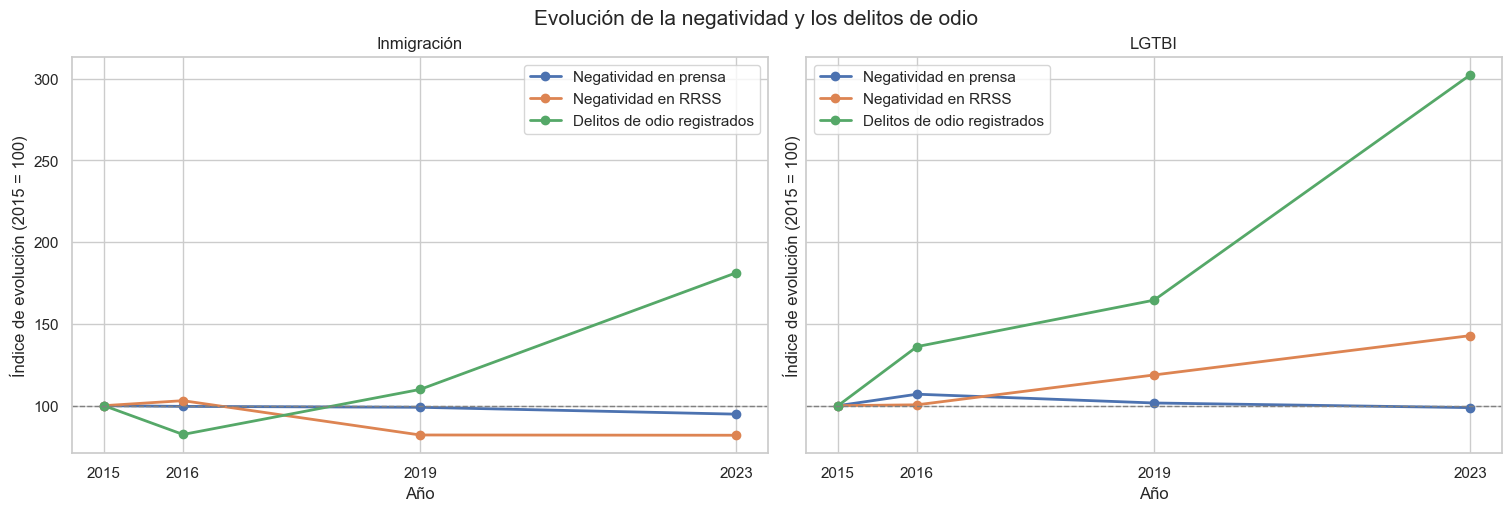

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=True,
    constrained_layout=True
)

nombres_variables = {
    "indice_negatividad_prensa": "Negatividad en prensa",
    "indice_negatividad_rrss": "Negatividad en RRSS",
    "indice_delitos_tema_por_100k": "Delitos de odio registrados"
}

for ax, tema_actual in zip(
    axes,
    ["Inmigración", "LGTBI"]
):
    datos_tema = datos_indices[
        datos_indices["tema"] == tema_actual
    ].copy()

    for variable, nombre in nombres_variables.items():
        ax.plot(
            datos_tema["anio"],
            datos_tema[variable],
            marker="o",
            linewidth=2,
            label=nombre
        )

    ax.axhline(
        100,
        color="gray",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(tema_actual)
    ax.set_xlabel("Año")
    ax.set_ylabel("Índice de evolución (2015 = 100)")
    ax.set_xticks([2015, 2016, 2019, 2023])
    ax.legend()

fig.suptitle(
    "Evolución de la negatividad y los delitos de odio",
    fontsize=15
)

plt.show()

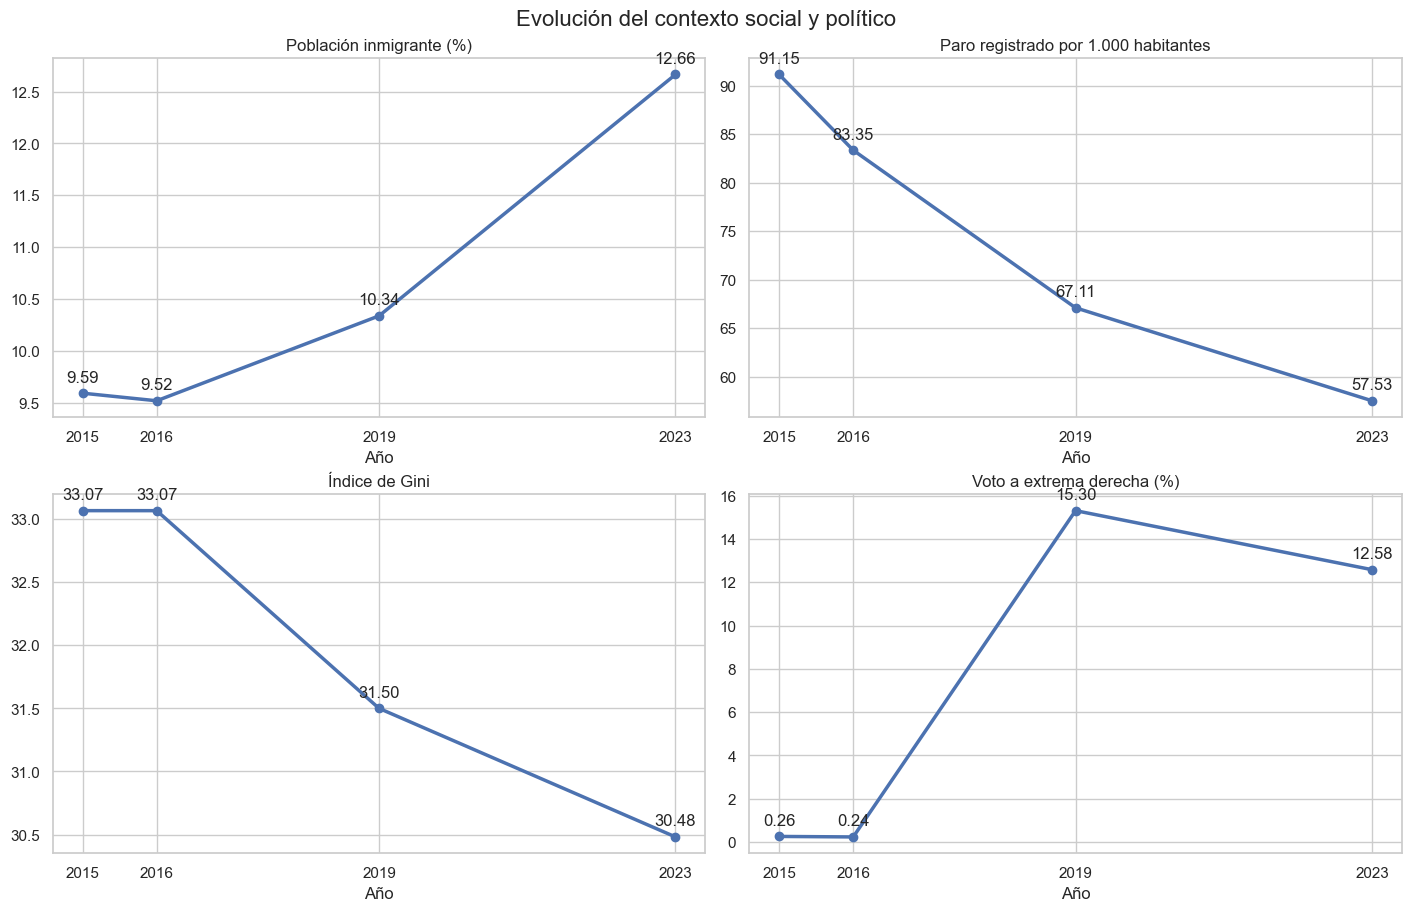

In [21]:
# ============================================================
# EVOLUCIÓN DE LOS PRINCIPALES INDICADORES DE CONTEXTO
# ============================================================

indicadores_contexto = {
    "pct_inmigrantes": "Población inmigrante (%)",
    "paro_por_1000": "Paro registrado por 1.000 habitantes",
    "Gini": "Índice de Gini",
    "pct_Extrema derecha": "Voto a extrema derecha (%)"
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    constrained_layout=True
)

for ax, (columna, titulo) in zip(
    axes.flatten(),
    indicadores_contexto.items()
):
    ax.plot(
        contexto_nacional["anio"],
        contexto_nacional[columna],
        marker="o",
        linewidth=2.5
    )

    for x, y in zip(
        contexto_nacional["anio"],
        contexto_nacional[columna]
    ):
        ax.annotate(
            f"{y:.2f}",
            (x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center"
        )

    ax.set_title(titulo)
    ax.set_xlabel("Año")
    ax.set_xticks([2015, 2016, 2019, 2023])

fig.suptitle(
    "Evolución del contexto social y político",
    fontsize=16
)

plt.show()

In [22]:
# ============================================================
# EXPORTAR LAS TABLAS FINALES
# ============================================================

contexto_nacional.to_csv(
    RUTA_RESULTADOS
    / "contexto_nacional_anual.csv",
    index=False,
    encoding="utf-8-sig"
)

sentimiento_anual.to_csv(
    RUTA_RESULTADOS
    / "sentimiento_prensa_rrss_anual.csv",
    index=False,
    encoding="utf-8-sig"
)

analisis_integrado[columnas_finales].to_csv(
    RUTA_RESULTADOS
    / "analisis_integrado_final.csv",
    index=False,
    encoding="utf-8-sig"
)

datos_indices.to_csv(
    RUTA_RESULTADOS
    / "indices_evolucion_2015_100.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos exportados en:")
print(RUTA_RESULTADOS)

Archivos exportados en:
C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\tables\analisis_integrado
